In [2]:
import pandas as pd

train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print("TRAIN SHAPE:", train.shape)
print("TEST SHAPE:", test.shape)

print("\n--- Missing Values: TRAIN ---")
print(train.isnull().sum())

print("\n--- Missing Values: TEST ---")
print(test.isnull().sum())

print("\n--- Duplicate Rows: TRAIN ---")
print(train.duplicated().sum())

print("\n--- Duplicate Rows: TEST ---")
print(test.duplicated().sum())

TRAIN SHAPE: (1296675, 23)
TEST SHAPE: (555719, 23)

--- Missing Values: TRAIN ---
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

--- Missing Values: TEST ---
Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street    

Fraud Distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

Fraud Percentage:
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


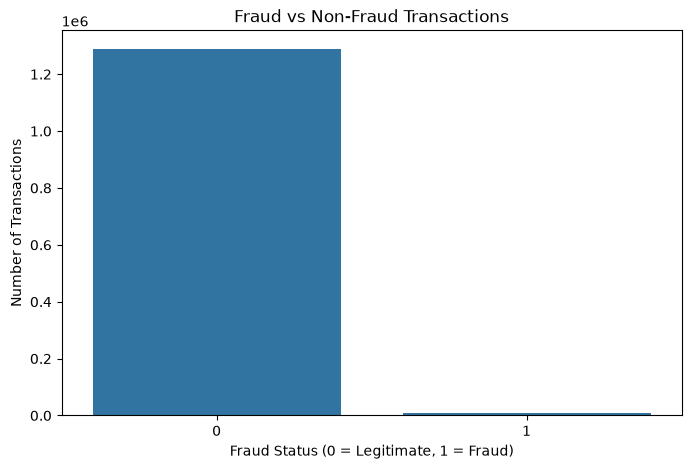

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Fraud Distribution:")
print(train["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(train["is_fraud"].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))
sns.countplot(x="is_fraud", data=train)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [4]:
print("Transaction Amount Statistics:")
print(train.groupby("is_fraud")["amt"].describe())

Transaction Amount Statistics:
              count        mean         std   min       25%      50%      75%  \
is_fraud                                                                        
0         1289169.0   67.667110  154.007971  1.00    9.6100   47.280   82.540   
1            7506.0  531.320092  390.560070  1.06  245.6625  396.505  900.875   

               max  
is_fraud            
0         28948.90  
1          1376.04  


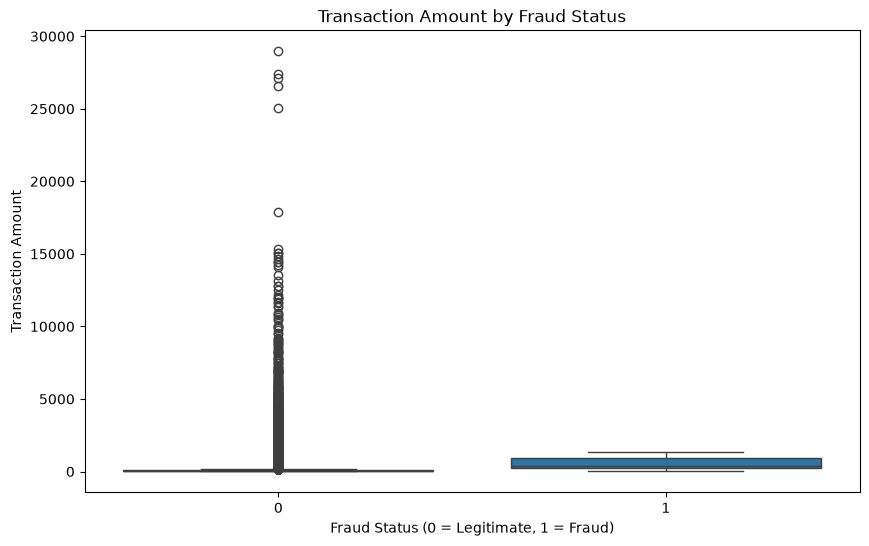

In [5]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="is_fraud",
    y="amt",
    data=train
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

In [6]:
category_fraud = (
    train.groupby("category")["is_fraud"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

category_fraud["fraud_rate"] = (
    category_fraud["sum"] / category_fraud["count"] * 100
)

print(category_fraud)

                 count   sum  fraud_rate
category                                
grocery_pos     123638  1743    1.409761
shopping_net     97543  1713    1.756149
misc_net         63287   915    1.445795
shopping_pos    116672   843    0.722538
gas_transport   131659   618    0.469394
misc_pos         79655   250    0.313853
kids_pets       113035   239    0.211439
entertainment    94014   233    0.247835
personal_care    90758   220    0.242403
home            123115   198    0.160825
food_dining      91461   151    0.165098
grocery_net      45452   134    0.294817
health_fitness   85879   133    0.154869
travel           40507   116    0.286370


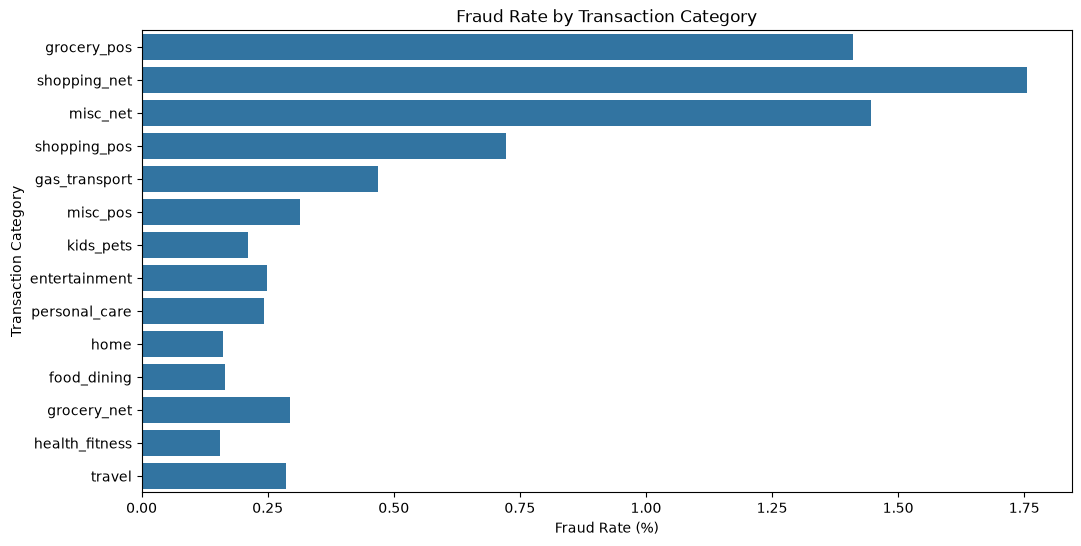

In [7]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=category_fraud["fraud_rate"],
    y=category_fraud.index
)

plt.title("Fraud Rate by Transaction Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Transaction Category")
plt.show()

In [8]:
gender_fraud = (
    train.groupby("gender")["is_fraud"]
    .agg(["count", "sum"])
)

gender_fraud["fraud_rate"] = (
    gender_fraud["sum"] / gender_fraud["count"] * 100
)

print(gender_fraud)

         count   sum  fraud_rate
gender                          
F       709863  3735    0.526158
M       586812  3771    0.642625


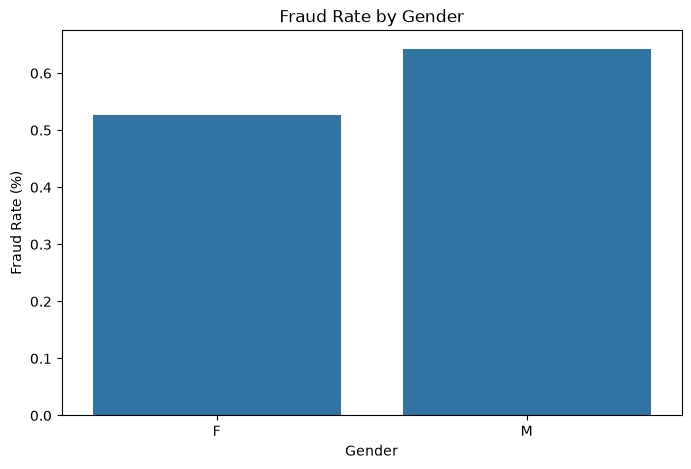

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_fraud.index,
    y=gender_fraud["fraud_rate"]
)

plt.title("Fraud Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Fraud Rate (%)")
plt.show()

In [11]:
train["trans_date_trans_time"] = pd.to_datetime(
    train["trans_date_trans_time"]
)

train["transaction_hour"] = (
    train["trans_date_trans_time"].dt.hour
)

hourly_fraud = (
    train.groupby("transaction_hour")["is_fraud"]
    .agg(["count", "sum"])
)

hourly_fraud["fraud_rate"] = (
    hourly_fraud["sum"] / hourly_fraud["count"] * 100
)

print(hourly_fraud)

                  count   sum  fraud_rate
transaction_hour                         
0                 42502   635    1.494047
1                 42869   658    1.534909
2                 42656   625    1.465210
3                 42769   609    1.423929
4                 41863    46    0.109882
5                 42171    60    0.142278
6                 42300    40    0.094563
7                 42203    56    0.132692
8                 42505    49    0.115281
9                 42185    47    0.111414
10                42271    40    0.094628
11                42082    42    0.099805
12                65257    67    0.102671
13                65314    80    0.122485
14                64885    86    0.132542
15                65391    79    0.120812
16                65726    76    0.115632
17                65450    78    0.119175
18                66051    81    0.122633
19                65508    81    0.123649
20                65098    62    0.095241
21                65533    74    0

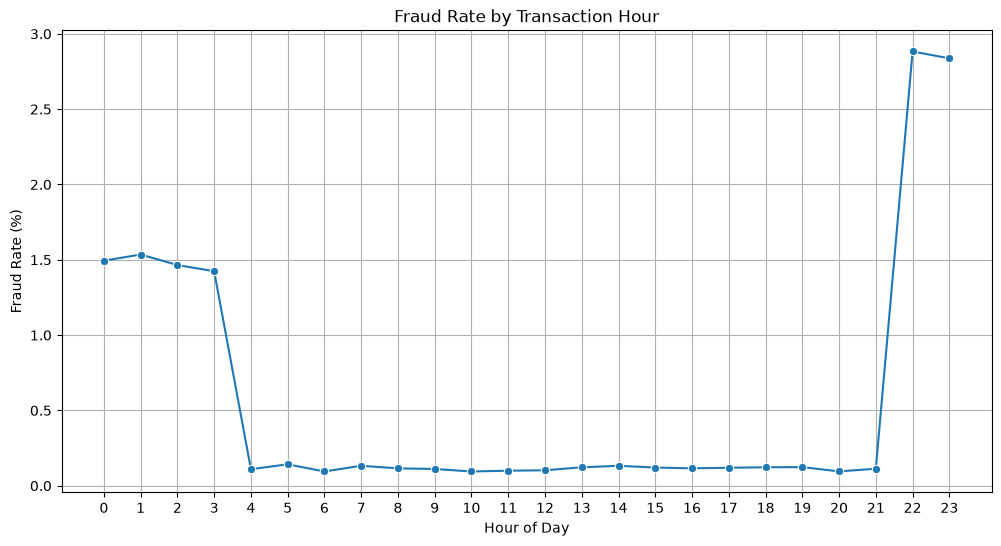

In [12]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud["fraud_rate"],
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(True)
plt.show()